In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib
import pandas as pd
import seaborn as sns
import os


import warnings
warnings.filterwarnings('ignore')

In [13]:
y = joblib.load('NN_8K_merged_labels.joblib')
y = np.array(y)
expected_folder = '/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/expected'
file_ids = sorted([f.split('.')[0] for f in os.listdir(expected_folder) if f.endswith('.jpg')])

assert len(file_ids) == len(y)

In [35]:
class ThreeChannelDiffDatasetFromFolders(Dataset):
    def __init__(self, expected_folder, actual_folder, diff_folder,
                 file_ids, labels,
                 target_size=(224, 224),
                 mean=(0.485, 0.456, 0.406),
                 std=(0.229, 0.224, 0.225),
                 is_train=False,
                 ext='.png'):  # расширение файлов, можно изменить
        """
        Параметры:
            expected_folder, actual_folder, diff_folder: папки с изображениями
            file_ids: список идентификаторов (например, ['img_001', 'img_002', ...])
            labels: список меток (0/1) в том же порядке
            target_size: (H, W) для ресайза
            mean, std: для нормализации
            is_train: флаг для аугментаций
            ext: расширение файлов (например, '.jpg', '.png')
        """
        self.expected_folder = expected_folder
        self.actual_folder = actual_folder
        self.diff_folder = diff_folder
        self.file_ids = file_ids
        self.labels = labels
        self.target_size = target_size
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)
        self.is_train = is_train
        self.ext = ext

    def __len__(self):
        return len(self.file_ids)

    def __getitem__(self, idx):
        # Формируем пути к трём файлам
        base = self.file_ids[idx]
        exp_path = os.path.join(self.expected_folder, base + self.ext)
        act_path = os.path.join(self.actual_folder, base + self.ext)
        diff_path = os.path.join(self.diff_folder, base + self.ext)

        # Загружаем изображения и приводим к 2D (H, W) как float32 [0, 1]
        exp = self._load_and_to_2d(exp_path)
        act = self._load_and_to_2d(act_path)
        diff = self._load_and_to_2d(diff_path)

        # Стек -> (3, H, W) в float32 [0, 1]
        combined = np.stack([exp, act, diff], axis=0).astype(np.float32)
        tensor = torch.from_numpy(combined)

        # Ресайз, если нужно
        if tensor.shape[1:] != self.target_size:
            tensor = TF.resize(tensor, self.target_size, antialias=True)

        # Аугментации (только для train)
        if self.is_train:
            if torch.rand(1) < 0.5:
                tensor = TF.hflip(tensor)
            angle = torch.randint(-10, 10, (1,)).item()
            tensor = TF.rotate(tensor, angle)
            # При желании можно добавить ColorJitter – но для трёх каналов
            # проще сделать через kornia или реализовать самостоятельно

        # Нормализация
        tensor = (tensor - self.mean) / self.std

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return tensor, label

    # @staticmethod
    # def _load_and_to_2d(path):
    #     """Загружает изображение, приводит к grayscale (2D) и нормализует в [0,1]"""
    #     img = Image.open(path).convert('RGB')  # всегда загружаем как RGB
    #     # Преобразуем в numpy (H, W, 3)
    #     arr = np.array(img, dtype=np.float32) / 255.0
    #     # Усредняем по каналам -> (H, W)
    #     return np.mean(arr, axis=-1)

    def _load_and_to_2d(self, path):
        """Загружает изображение, приводит к grayscale (2D), ресайзит и нормализует в [0,1]"""
        img = Image.open(path).convert('RGB')
        img = img.resize(self.target_size, Image.Resampling.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        return np.mean(arr, axis=-1)   # (H, W)

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


class DiffClassifier(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True):
        super(DiffClassifier, self).__init__()
        
        # Загружаем предобученную MobileNetV2
        self.backbone = models.mobilenet_v2(pretrained=True)
        
        # Замораживаем backbone (опционально)
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False
        
        # Заменяем классификатор
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels


def train_model_from_folders(file_ids, y,
                             expected_folder, actual_folder, diff_folder,
                             num_epochs=30,
                             batch_size=8,
                             learning_rate=0.001,
                             freeze_backbone=True,
                             early_stopping_patience=5,
                             ext='.jpg'):
    """
    Параметры:
        file_ids: список идентификаторов (например, ['0', '1', ...])
        y: метки классов
        expected_folder, actual_folder, diff_folder: пути к папкам
        ext: расширение файлов
    Остальные параметры как раньше.
    """

    # Разбиение на train/test
    ids_train, ids_test, y_train, y_test = train_test_split(
        file_ids, y,
        test_size=0.3,
        random_state=69
    )

    # Дополнительное разбиение train -> train/val (стратификация по y_train)
    ids_train, ids_val, y_train, y_val = train_test_split(
        ids_train, y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=69
    )

    print(f"Train: {len(ids_train)}, Val: {len(ids_val)}, Test: {len(ids_test)}")

    # Создаём датасеты
    train_dataset = ThreeChannelDiffDatasetFromFolders(
        expected_folder, actual_folder, diff_folder,
        ids_train, y_train,
        is_train=True,
        ext=ext
    )

    val_dataset = ThreeChannelDiffDatasetFromFolders(
        expected_folder, actual_folder, diff_folder,
        ids_val, y_val,
        is_train=False,
        ext=ext
    )

    test_dataset = ThreeChannelDiffDatasetFromFolders(
        expected_folder, actual_folder, diff_folder,
        ids_test, y_test,
        is_train=False,
        ext=ext
    )

    # DataLoader'ы – уменьшаем num_workers, чтобы не плодить процессы
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                             shuffle=False, num_workers=0, pin_memory=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = DiffClassifier(num_classes=2, freeze_backbone=freeze_backbone)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    
    # optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    backbone_params = model.backbone.features.parameters()
    head_params = model.backbone.classifier.parameters()
    
    optimizer = optim.Adam([
        {'params': backbone_params, 'lr': 0.000001},
        {'params': head_params, 'lr': 0.0001}
    ])
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      patience=5, factor=0.5)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    wait = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Model saved with Val Acc: {val_acc:.2f}% (epoch {best_epoch})")
            wait = 0  # сбрасываем счётчик при улучшении
        else:
            wait += 1
            print(f"No improvement for {wait} epochs (best: {best_val_acc:.2f}% at epoch {best_epoch})")
            if wait >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break  # выход из цикла
            

    # Загружаем лучшую модель и тестируем
    model.load_state_dict(torch.load('best_model.pth'))

    test_loss, test_acc, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion, device
    )

    print(f"\n{'='*60}")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=['Not Bug', 'Bug']))

    # Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=100)
    plt.show()

    return model, test_preds, test_labels, ids_test, test_loader, device

Train: 4226, Val: 1057, Test: 2265
Using device: cpu

Epoch 1/30


Validation: 100%|███████████████████████████████| 67/67 [01:13<00:00,  1.10s/it]


Train Loss: 0.4445, Train Acc: 81.99%
Val Loss: 0.3143, Val Acc: 85.43%
Model saved with Val Acc: 85.43% (epoch 1)

Epoch 2/30


Validation: 100%|███████████████████████████████| 67/67 [01:12<00:00,  1.09s/it]


Train Loss: 0.2813, Train Acc: 88.97%
Val Loss: 0.2656, Val Acc: 87.70%
Model saved with Val Acc: 87.70% (epoch 2)

Epoch 3/30


...

Train Loss: 0.2088, Train Acc: 91.43%
Val Loss: 0.2511, Val Acc: 89.69%
No improvement for 4 epochs (best: 92.15% at epoch 8)

Epoch 13/30


Validation: 100%|███████████████████████████████| 67/67 [01:13<00:00,  1.09s/it]


Train Loss: 0.2134, Train Acc: 91.62%
Val Loss: 0.2115, Val Acc: 91.01%
No improvement for 5 epochs (best: 92.15% at epoch 8)
Early stopping triggered after 13 epochs.


Validation: 100%|█████████████████████████████| 142/142 [02:37<00:00,  1.11s/it]



Test Loss: 0.1930, Test Acc: 93.16%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.94      0.93      0.93      1150
         Bug       0.92      0.94      0.93      1115

    accuracy                           0.93      2265
   macro avg       0.93      0.93      0.93      2265
weighted avg       0.93      0.93      0.93      2265



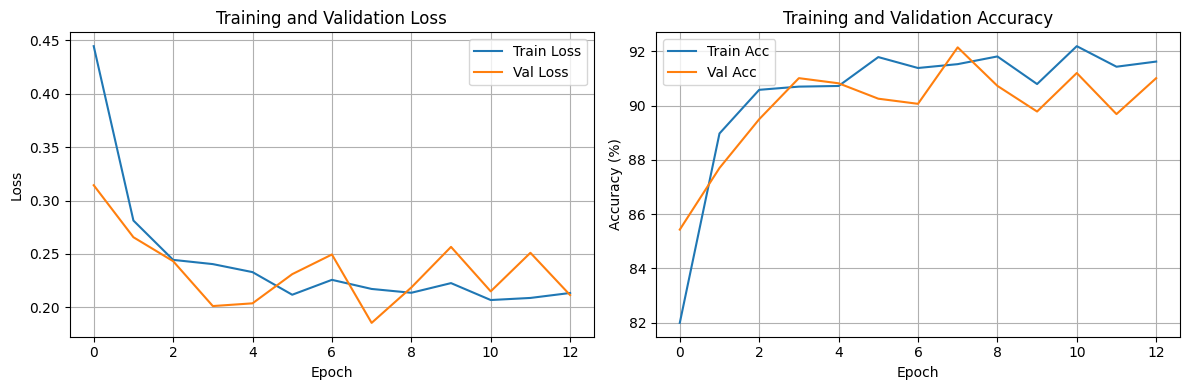

In [33]:
# learning rate 0.0001 Dropout 0.2

# Test Loss: 0.1930, Test Acc: 93.16%

# Classification Report:
#               precision    recall  f1-score   support

#      Not Bug       0.94      0.93      0.93      1150
#          Bug       0.92      0.94      0.93      1115

#     accuracy                           0.93      2265
#    macro avg       0.93      0.93      0.93      2265
# weighted avg       0.93      0.93      0.93      2265

# model, test_preds, test_labels, test_ids, test_loader, device = train_model_from_folders(
#     file_ids=file_ids,
#     y=y,
#     expected_folder='/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/expected',
#     actual_folder='/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/actual',
#     diff_folder='/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/diff',
#     num_epochs=30,
#     batch_size=16,
#     learning_rate=0.0001,
#     freeze_backbone=True
# )

Train: 4226, Val: 1057, Test: 2265
Using device: cpu

Epoch 1/15


Validation: 100%|███████████████████████████████| 67/67 [01:12<00:00,  1.08s/it]


Train Loss: 0.3899, Train Acc: 84.57%
Val Loss: 0.2111, Val Acc: 90.54%
Model saved with Val Acc: 90.54% (epoch 1)

Epoch 2/15


Validation: 100%|███████████████████████████████| 67/67 [01:11<00:00,  1.07s/it]


Train Loss: 0.2135, Train Acc: 91.67%
Val Loss: 0.1878, Val Acc: 91.30%
Model saved with Val Acc: 91.30% (epoch 2)

Epoch 3/15


...

Train Loss: 0.0861, Train Acc: 96.92%
Val Loss: 0.0720, Val Acc: 96.97%
No improvement for 1 epochs (best: 97.73% at epoch 13)

Epoch 15/15


Validation: 100%|███████████████████████████████| 67/67 [01:11<00:00,  1.07s/it]


Train Loss: 0.0881, Train Acc: 97.04%
Val Loss: 0.0484, Val Acc: 98.39%
Model saved with Val Acc: 98.39% (epoch 15)


Validation: 100%|█████████████████████████████| 142/142 [02:41<00:00,  1.14s/it]



Test Loss: 0.0595, Test Acc: 97.84%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.97      0.98      0.98      1150
         Bug       0.98      0.97      0.98      1115

    accuracy                           0.98      2265
   macro avg       0.98      0.98      0.98      2265
weighted avg       0.98      0.98      0.98      2265



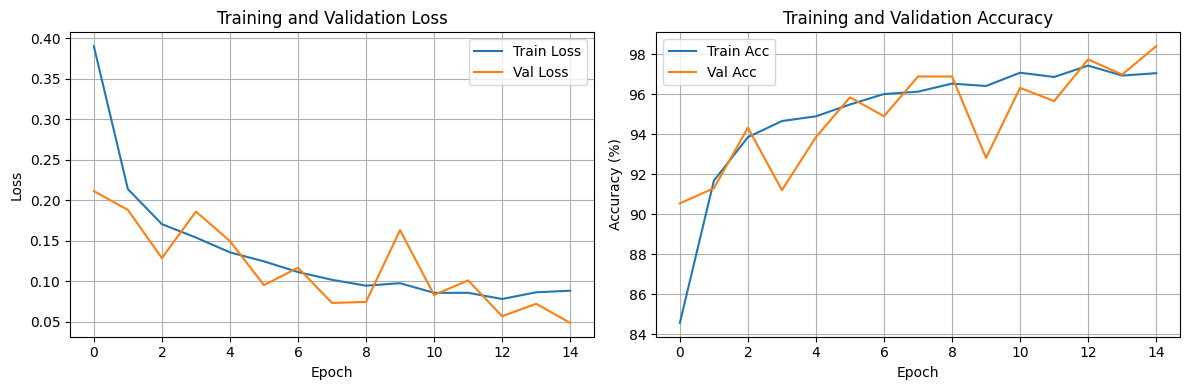

In [16]:
# freeze_backbone=False learning_rate=0.000001 num_epochs=15

# backbone_params = model.backbone.features.parameters()
# head_params = model.backbone.classifier.parameters()

# optimizer = optim.Adam([
#     {'params': backbone_params, 'lr': 0.000001},
#     {'params': head_params, 'lr': 0.0001}
# ])


# Test Loss: 0.0595, Test Acc: 97.84%

# Classification Report:
#               precision    recall  f1-score   support

#      Not Bug       0.97      0.98      0.98      1150
#          Bug       0.98      0.97      0.98      1115

#     accuracy                           0.98      2265
#    macro avg       0.98      0.98      0.98      2265
# weighted avg       0.98      0.98      0.98      2265

# model, test_preds, test_labels, test_ids, test_loader, device = train_model_from_folders(
#     file_ids=file_ids,
#     y=y,
#     expected_folder='/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/expected',
#     actual_folder='/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/actual',
#     diff_folder='/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/diff',
#     num_epochs=15,
#     batch_size=16,
#     learning_rate=0.000001,
#     freeze_backbone=False
# )

In [17]:
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DiffClassifier(num_classes=2, freeze_backbone=True)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model = model.to(device)
model.eval()
summary(model, input_size=(16, 3, 256, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
DiffClassifier                                          [16, 2]                   --
├─MobileNetV2: 1-1                                      [16, 2]                   --
│    └─Sequential: 2-1                                  [16, 1280, 8, 16]         --
│    │    └─Conv2dNormActivation: 3-1                   [16, 32, 128, 256]        (928)
│    │    └─InvertedResidual: 3-2                       [16, 16, 128, 256]        (896)
│    │    └─InvertedResidual: 3-3                       [16, 24, 64, 128]         (5,136)
│    │    └─InvertedResidual: 3-4                       [16, 24, 64, 128]         (8,832)
│    │    └─InvertedResidual: 3-5                       [16, 32, 32, 64]          (10,000)
│    │    └─InvertedResidual: 3-6                       [16, 32, 32, 64]          (14,848)
│    │    └─InvertedResidual: 3-7                       [16, 32, 32, 64]          (14,848)
│    │    └─InvertedResidu

In [34]:
y_final_test = joblib.load('NN_8K_merged_test_labels.joblib')
y_final_test = np.array(y_final_test)
expected_folder = '/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged_test/expected'
file_ids = sorted([f.split('.')[0] for f in os.listdir(expected_folder) if f.endswith('.png')])

assert len(file_ids) == len(y_final_test)

In [36]:
base = '/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged_test'
expected_folder = os.path.join(base, 'expected')
actual_folder   = os.path.join(base, 'actual')
diff_folder     = os.path.join(base, 'diff')
ext = '.png'


final_dataset = ThreeChannelDiffDatasetFromFolders(
    expected_folder=expected_folder,
    actual_folder=actual_folder,
    diff_folder=diff_folder,
    file_ids=file_ids,
    labels=y_final_test,
    is_train=False,
    ext=ext
)

final_loader = DataLoader(
    final_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


def evaluate_final(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Final test'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

criterion = torch.nn.CrossEntropyLoss()

test_loss, test_acc, test_preds, test_labels = evaluate_final(
    model, final_loader, criterion, device
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Not Bug', 'Bug']))
print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

Final test: 100%|███████████████████████████████| 78/78 [00:33<00:00,  2.33it/s]

Final Test Loss: 0.3739
Final Test Accuracy: 86.75%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.83      0.94      0.88       319
         Bug       0.93      0.79      0.85       300

    accuracy                           0.87       619
   macro avg       0.88      0.87      0.87       619
weighted avg       0.87      0.87      0.87       619

Confusion Matrix:
[[300  19]
 [ 63 237]]


Всего ошибок: 82
Пропущенных багов (False Negatives): 63


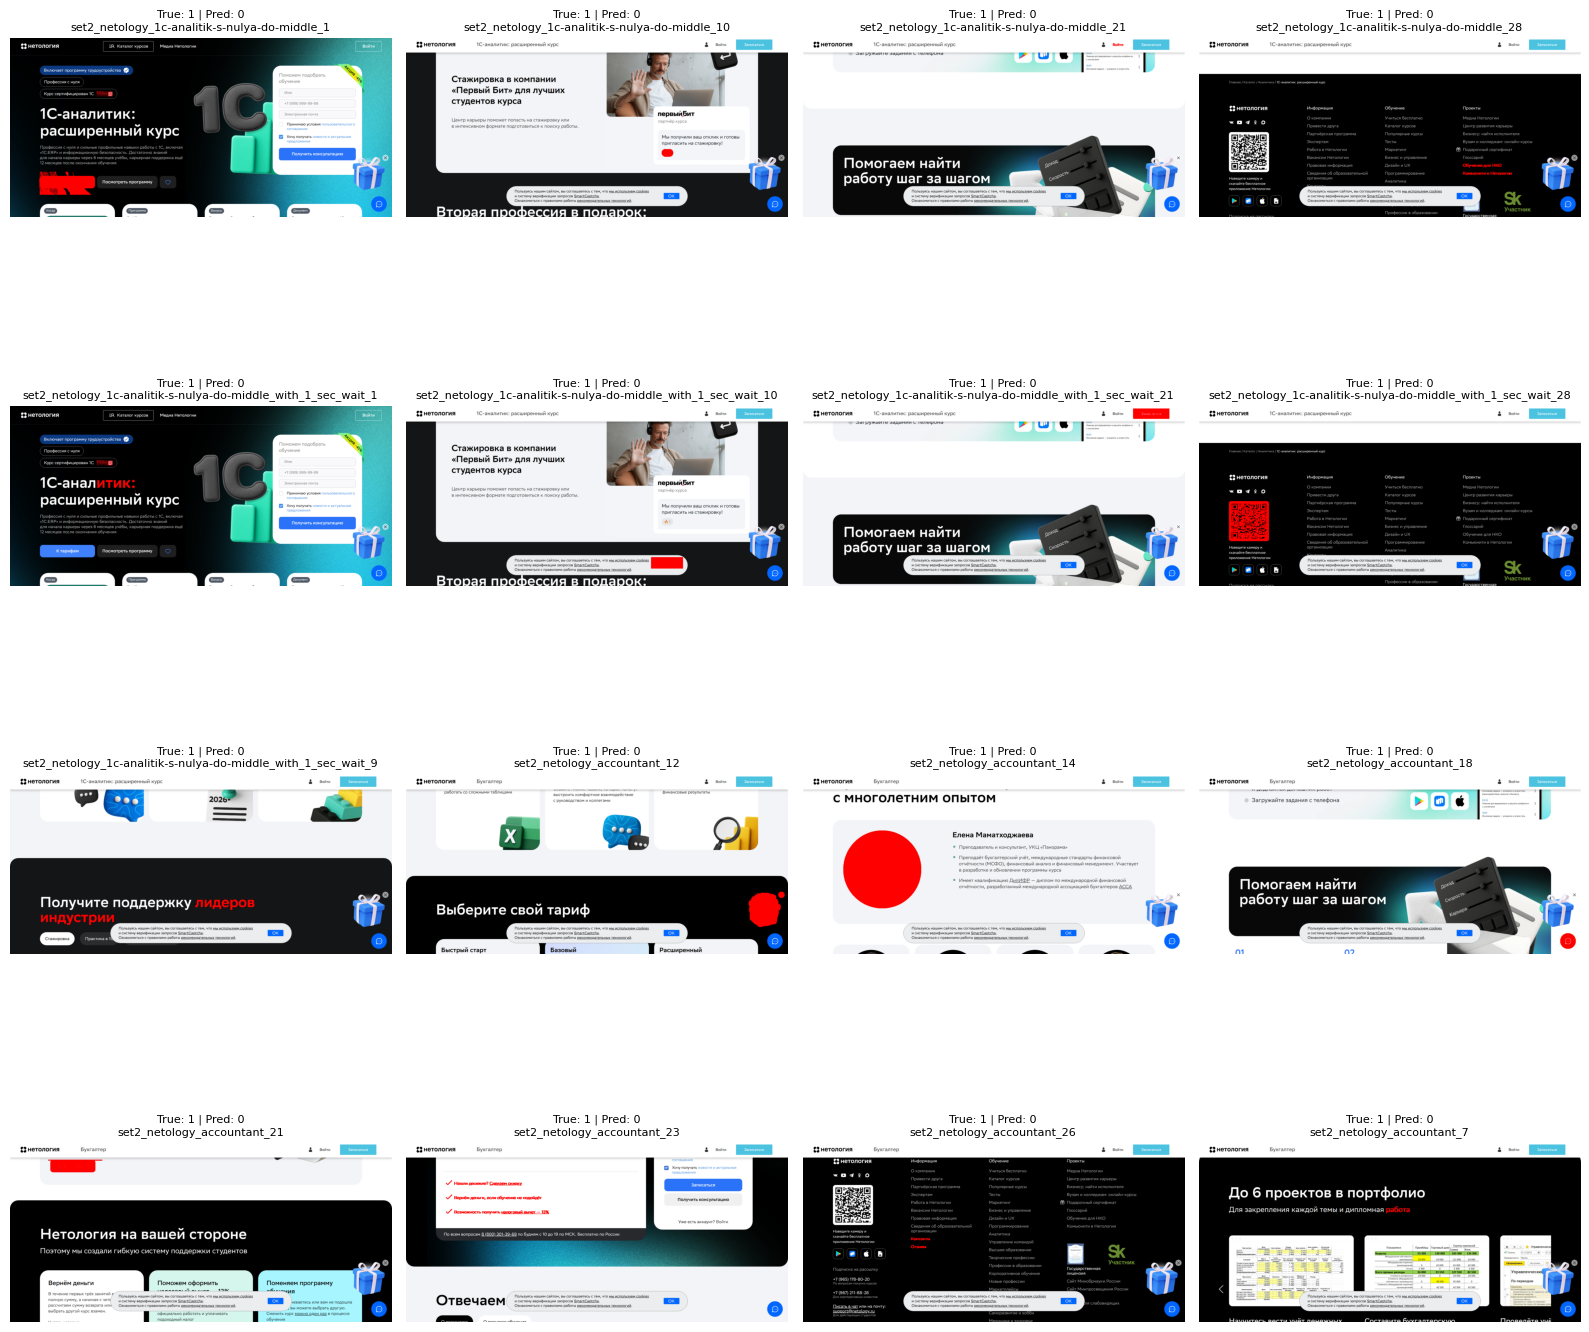

In [41]:
error_indices = [
    i for i, (pred, true) in enumerate(zip(test_preds, test_labels))
    if pred != true
]

print(f"Всего ошибок: {len(error_indices)}")

false_negative_indices = [
    i for i in error_indices
    if test_labels[i] == 1 and test_preds[i] == 0
]

print(f"Пропущенных багов (False Negatives): {len(false_negative_indices)}")


N = min(16, len(false_negative_indices))  # сколько показать
error_indices_to_show = false_negative_indices[:N]

cols = 4
rows = (N + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.ravel() if N > 1 else [axes]  # чтобы работало и с одним графиком

for ax, idx in zip(axes, error_indices_to_show):
    file_id = file_ids[idx]          # имя файла без расширения
    diff_path = os.path.join(diff_folder, f"{file_id}{ext}")

    diff_img = Image.open(diff_path).convert('RGB')

    ax.imshow(diff_img)
    ax.set_title(
        f"True: {test_labels[idx]} | Pred: {test_preds[idx]}\n{file_id}",
        fontsize=8
    )
    ax.axis('off')

for ax in axes[N:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [49]:
base = '/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged_test'
expected_folder = os.path.join(base, 'expected')
actual_folder   = os.path.join(base, 'actual')
diff_folder     = os.path.join(base, 'diff')
ext = '.png'

print(f"Всего данных для дообучения: {len(file_ids)}")

train_val_ids, test_ids, y_train_val, y_test = train_test_split(
    file_ids, y_final_test,
    test_size=0.15,
    stratify=y_final_test,
    random_state=42
)

val_ratio = 0.15 / 0.85  # ≈0.1765
train_ids, val_ids, y_train, y_val = train_test_split(
    train_val_ids, y_train_val,
    test_size=val_ratio,
    stratify=y_train_val,
    random_state=42
)

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

Всего данных для дообучения: 619
Train: 433, Val: 93, Test: 93


In [50]:
# Обучающий датасет с аугментациями
train_dataset = ThreeChannelDiffDatasetFromFolders(
    expected_folder=expected_folder,
    actual_folder=actual_folder,
    diff_folder=diff_folder,
    file_ids=train_ids,
    labels=y_train,
    is_train=True,
    ext=ext
)


val_dataset = ThreeChannelDiffDatasetFromFolders(
    expected_folder=expected_folder,
    actual_folder=actual_folder,
    diff_folder=diff_folder,
    file_ids=val_ids,
    labels=y_val,
    is_train=False,
    ext=ext
)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DiffClassifier(num_classes=2, freeze_backbone=True)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)

for param in model.backbone.features.parameters():
    param.requires_grad = False

head_params = model.backbone.classifier.parameters()
optimizer = optim.Adam([
    {'params': head_params, 'lr': 1e-5}
])

criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [52]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

num_epochs = 15
best_val_acc = 0.0
patience = 5
wait = 0

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        torch.save(model.state_dict(), 'best_model_finetuned.pth')
        print(f'Saved new best model with val acc {val_acc:.2f}%')
    else:
        wait += 1
        if wait >= patience:
            print(f'Early stopping after {epoch+1} epochs')
            break


Epoch 1/15


Val: 100%|██████████████████████████████████████| 12/12 [00:05<00:00,  2.22it/s]


Train Loss: 0.4379, Acc: 85.22%
Val Loss: 0.5024, Acc: 79.57%
Saved new best model with val acc 79.57%

Epoch 2/15


Val: 100%|██████████████████████████████████████| 12/12 [00:05<00:00,  2.31it/s]


Train Loss: 0.5057, Acc: 83.37%
Val Loss: 0.4558, Acc: 79.57%

Epoch 3/15


...

Train Loss: 0.4292, Acc: 83.60%
Val Loss: 0.3910, Acc: 84.95%

Epoch 9/15


Val: 100%|██████████████████████████████████████| 12/12 [00:05<00:00,  2.25it/s]


Train Loss: 0.3530, Acc: 86.61%
Val Loss: 0.4784, Acc: 78.49%

Epoch 10/15


Val: 100%|██████████████████████████████████████| 12/12 [00:05<00:00,  2.27it/s]

Train Loss: 0.3441, Acc: 85.45%
Val Loss: 0.4550, Acc: 80.65%
Early stopping after 10 epochs


In [53]:
# Создаём тестовый датасет (без аугментаций)
test_dataset = ThreeChannelDiffDatasetFromFolders(
    expected_folder=expected_folder,
    actual_folder=actual_folder,
    diff_folder=diff_folder,
    file_ids=test_ids,          # список имён файлов без расширения
    labels=y_test,              # метки (numpy array)
    is_train=False,             # ВАЖНО: отключаем аугментации
    ext=ext
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DiffClassifier(num_classes=2, freeze_backbone=True)
model.load_state_dict(torch.load('best_model_finetuned.pth', map_location=device))
model.to(device)
model.eval()

def evaluate_test(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Test'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels


criterion = torch.nn.CrossEntropyLoss()

test_loss, test_acc, test_preds, test_labels = evaluate_test(
    model, test_loader, criterion, device
)

print(f"\n=== Тест после дообучения ===")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.2f}%")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Not Bug', 'Bug']))
print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

Test: 100%|█████████████████████████████████████| 12/12 [00:05<00:00,  2.30it/s]


=== Тест после дообучения ===
Loss: 0.5111
Accuracy: 82.80%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.81      0.88      0.84        48
         Bug       0.85      0.78      0.81        45

    accuracy                           0.83        93
   macro avg       0.83      0.83      0.83        93
weighted avg       0.83      0.83      0.83        93

Confusion Matrix:
[[42  6]
 [10 35]]


```
Final Test Loss: 0.3739
Final Test Accuracy: 86.75%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.83      0.94      0.88       319
         Bug       0.93      0.79      0.85       300

    accuracy                           0.87       619
   macro avg       0.88      0.87      0.87       619
weighted avg       0.87      0.87      0.87       619
```

Всего ошибок: 16
Пропущенных багов (False Negatives): 10


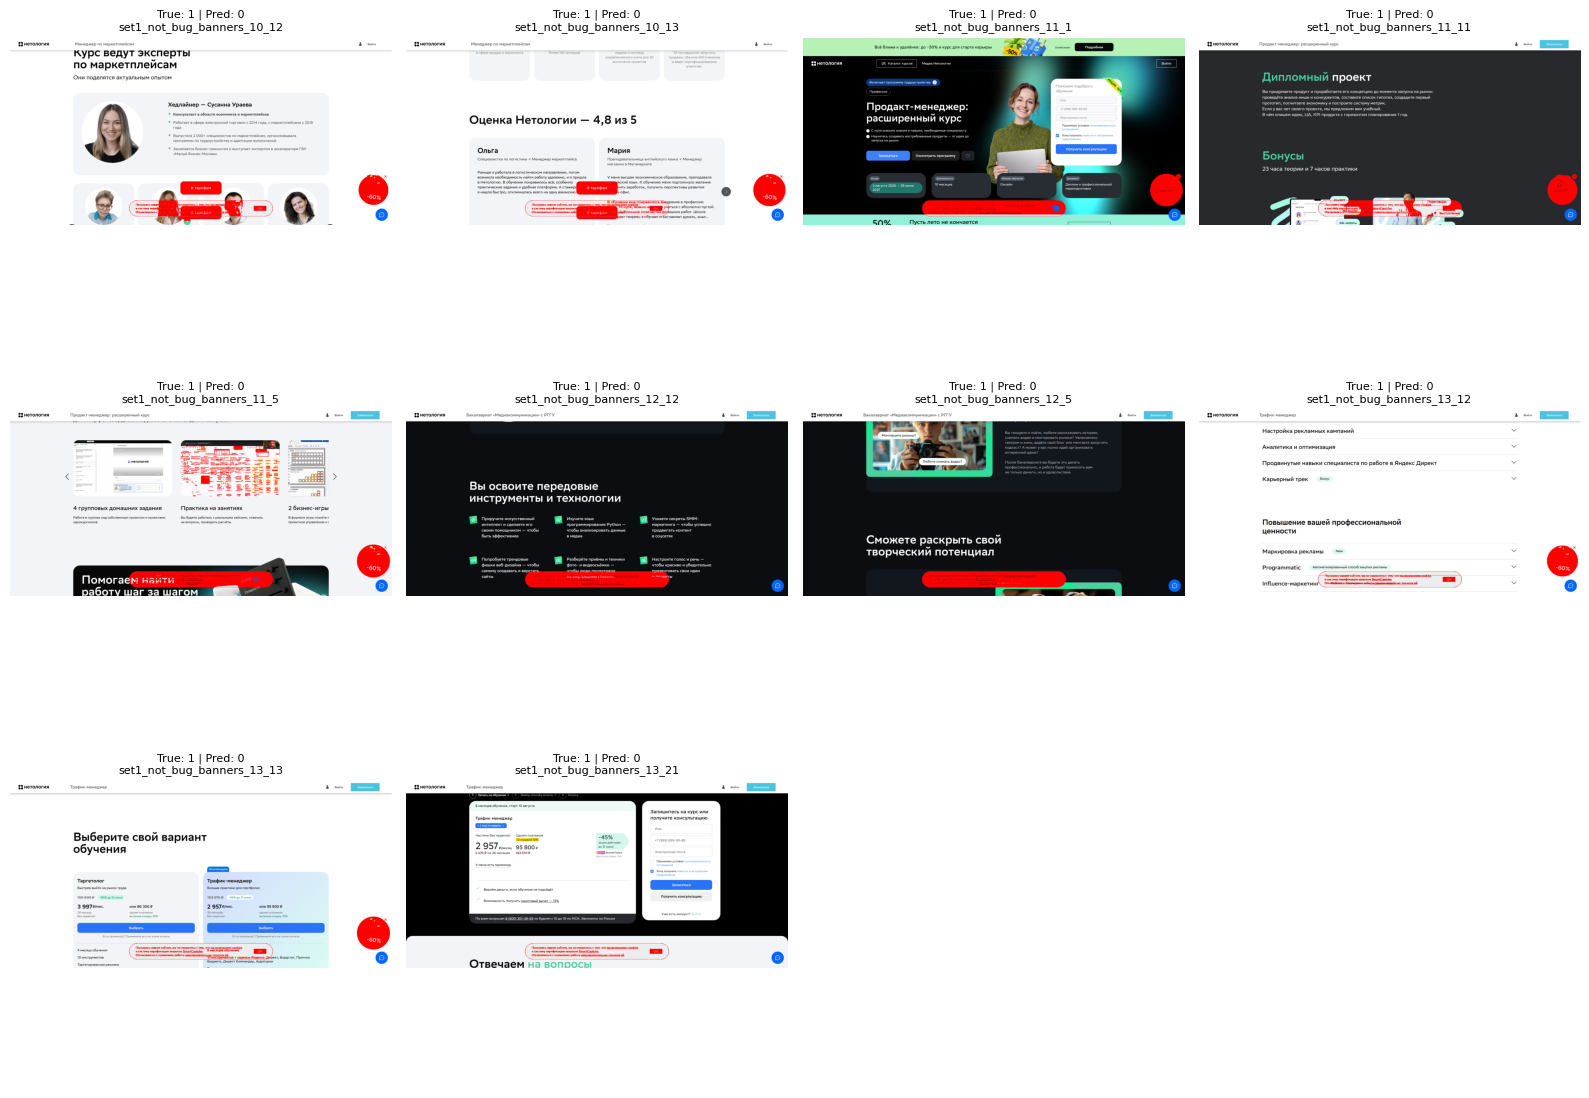

In [54]:
error_indices = [
    i for i, (pred, true) in enumerate(zip(test_preds, test_labels))
    if pred != true
]

print(f"Всего ошибок: {len(error_indices)}")

false_negative_indices = [
    i for i in error_indices
    if test_labels[i] == 1 and test_preds[i] == 0
]

print(f"Пропущенных багов (False Negatives): {len(false_negative_indices)}")


N = min(16, len(false_negative_indices))  # сколько показать
error_indices_to_show = false_negative_indices[:N]

cols = 4
rows = (N + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.ravel() if N > 1 else [axes]  # чтобы работало и с одним графиком

for ax, idx in zip(axes, error_indices_to_show):
    file_id = file_ids[idx]          # имя файла без расширения
    diff_path = os.path.join(diff_folder, f"{file_id}{ext}")

    diff_img = Image.open(diff_path).convert('RGB')

    ax.imshow(diff_img)
    ax.set_title(
        f"True: {test_labels[idx]} | Pred: {test_preds[idx]}\n{file_id}",
        fontsize=8
    )
    ax.axis('off')

for ax in axes[N:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [55]:
# Слишком мало данных! Дообучение провалилось.import numpy as np


In [58]:
from sklearn.metrics import precision_recall_curve, roc_curve, f1_score, classification_report, confusion_matrix

def get_probabilities(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # вероятность класса 1 (Bug)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_probs), np.array(all_labels)

model = DiffClassifier(num_classes=2, freeze_backbone=True)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)


val_probs, val_labels = get_probabilities(model, val_loader, device)
precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Оптимальный порог (по F1): {best_threshold:.4f}")
print(f"F1 при этом пороге: {f1_scores[best_idx]:.4f}")    

Оптимальный порог (по F1): 0.1908
F1 при этом пороге: 0.8660


In [59]:
test_probs, test_labels = get_probabilities(model, test_loader, device)
test_preds = (test_probs >= best_threshold).astype(int)

print(classification_report(test_labels, test_preds, target_names=['Not Bug', 'Bug']))
print(confusion_matrix(test_labels, test_preds))

              precision    recall  f1-score   support

     Not Bug       0.82      0.83      0.82        48
         Bug       0.82      0.80      0.81        45

    accuracy                           0.82        93
   macro avg       0.82      0.82      0.82        93
weighted avg       0.82      0.82      0.82        93

[[40  8]
 [ 9 36]]
